## Hybrid Decomposition + Residual LSTM (MSTL & Prophet)

Ini **menggantikan** draft `07_dani_dl_mstl.ipynb` (MSTL-as-feature) sebelumnya. Sesuai skema resmi
proyek, kategori **Hybrid** bukan "dekomposisi sebagai fitur tambahan", melainkan:

> Input: **Residual model utama** (gunakan hasil tuning dari Deep Learning)

Artinya arsitekturnya:

1. **Decompose** `Y = Trend + Seasonal + Residual` — via **MSTL** (causal, leak-free, seperti sebelumnya)
   atau **Prophet** (fit hanya di train, `make_future_dataframe` untuk extend ke test — pola yang sama
   persis dengan `03_dani_statistical.ipynb`, sudah leak-free by design).
2. `Trend + Seasonal` diekstrapolasi **secara deterministik** (bukan oleh LSTM).
3. **LSTM/BiLSTM memodelkan `Residual` saja** — pakai hyperparameter hasil tuning Optuna dari notebook 06
   (`look_back=12, 1 layer, units=128, dropout=0.0, lr=0.001847, batch=64`).
4. Prediksi akhir = `Trend_forecast + Seasonal_forecast + Residual_forecast`.

### 12 konfigurasi model

Dua decomposition backend (**MSTL**, **Prophet**) × enam slot arsitektur (**Uni-LSTM CI, Uni-LSTM RE,
Multi-LSTM, BiLSTM CI, BiLSTM RE, BiLSTM Multi**) — konsisten dengan struktur 6-slot yang dipakai di
notebook 04-07 sebelumnya, sekarang diterapkan ke residual, bukan raw target.

### Catatan penting soal hyperparameter reuse

Hasil tuning Optuna (nb06) dilakukan pada model **multivariate** (2-output, CI+RE) dan menghasilkan
arsitektur **plain LSTM** (bukan BiLSTM) sebagai yang terbaik. Untuk notebook ini:
- **Multi-LSTM** (MSTL & Prophet) langsung reuse hyperparameter tuning tersebut apa adanya.
- **Uni-LSTM CI/RE** dan varian **BiLSTM** mereuse NILAI hyperparameter yang sama (units, dropout,
  learning rate, batch size, look-back), hanya mengganti tipe layer / output_dim sesuai slot — karena
  tuning terpisah untuk tiap varian tidak dilakukan di tahap ini. Ini simplifikasi yang secara eksplisit
  dicatat di sini, dan menjadi salah satu alasan kenapa notebook 08 (tuned hybrid) akan tetap diperlukan.

### Metodologi evaluasi multistep — rolling-origin recursive forecasting

**Bukan** recursive tunggal sepanjang seluruh test set (itu yang menyebabkan `trend` collapse di
`06_dani_dl_mstl.ipynb` versi lama). Di sini yang di-recursive-forecast adalah **residual**, yang jauh
lebih stasioner (mean-reverting) dibanding trend — tapi tetap berisiko drift kalau dievaluasi naif.

Sebagai gantinya, dipakai **rolling-origin evaluation**:
- Ambil banyak titik awal (*origin*) yang tersebar di seluruh test set.
- Dari tiap origin, forecast recursive sejauh `H=24` jam ke depan (1 hari — selaras dengan tema
  *multiple seasonality* harian).
- Ukur error di tiap step `h=1..24`, lalu rata-ratakan across semua origin.

Ini memberi kurva "error vs horizon" yang langsung menjawab pertanyaan: apakah residual model ini
drift seiring bertambahnya horizon, atau tetap stabil? Trend & seasonal tidak pernah di-recursive-forecast
sama sekali — nilainya sudah deterministik/diketahui di titik manapun di masa depan.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

project_root = next(
    (
        parent
        for parent in [Path.cwd(), *Path.cwd().parents]
        if (parent / "src").exists()
    ),
    Path.cwd()
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loader import TimeSeriesDataLoader

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from prophet import Prophet

print("Project root:", project_root)
print("TensorFlow:", tf.__version__)

Project root: /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app
TensorFlow: 2.21.0


In [2]:
feature_path = (
    project_root
    / "data"
    / "processed"
    / "normalized"
    / "dataset_feature_engineered.csv"
)

df = pd.read_csv(feature_path)
df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
df = df.set_index("datetime").sort_index()

CI_COL = "carbon_intensity"
RE_COL = "renewable_percentage"

df_core = df.dropna(subset=[CI_COL, RE_COL]).copy()

TRAIN_RATIO = 0.8
train_size = int(len(df_core) * TRAIN_RATIO)

train_raw = df_core.iloc[:train_size].copy()
test_raw = df_core.iloc[train_size:].copy()
TRAIN_END_INDEX = train_raw.index[-1]

print("Shape:", df_core.shape)
print("Train:", train_raw.shape, train_raw.index.min(), "->", train_raw.index.max())
print("Test :", test_raw.shape, test_raw.index.min(), "->", test_raw.index.max())

Shape: (17496, 84)
Train: (13996, 84) 2024-01-03 00:00:00+00:00 -> 2025-08-08 03:00:00+00:00
Test : (3500, 84) 2025-08-08 04:00:00+00:00 -> 2025-12-31 23:00:00+00:00


## 1. Cyclical temporal features

Dipakai sebagai fitur auxiliary buat residual model (residual hasil dekomposisi mungkin masih menyisakan
sedikit struktur halus yang belum tertangkap sempurna oleh trend/seasonal profile).

In [3]:
TEMPORAL_CYCLICAL = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"]

loader_time = TimeSeriesDataLoader()
all_index_df = pd.DataFrame(index=df_core.index)
cyclical_full = loader_time.add_time_features(all_index_df)[TEMPORAL_CYCLICAL].copy()

print("Cyclical features ready:", TEMPORAL_CYCLICAL)

Cyclical features ready: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


## 2. MSTL — causal, leak-free decomposition

Sama persis dengan yang divalidasi di notebook sebelumnya: `trend` = trailing rolling mean,
`seasonal_24`/`seasonal_168` = profil periodik yang di-fit hanya dari train, `resid` = sisanya.

In [4]:
def compute_causal_decomposition(series, train_end_index, trend_window=168):
    trend = series.rolling(window=trend_window, min_periods=1).mean()
    deseasonalized = series - trend

    train_deseasonalized = deseasonalized.loc[:train_end_index]

    hour_profile = (
        train_deseasonalized.groupby(train_deseasonalized.index.hour).mean()
    )
    seasonal_24 = pd.Series(
        series.index.hour.map(hour_profile).astype(float), index=series.index
    )

    residual_after_24 = (
        train_deseasonalized.values
        - train_deseasonalized.index.hour.map(hour_profile).astype(float)
    )
    weekhour_key_train = train_deseasonalized.index.weekday * 24 + train_deseasonalized.index.hour
    weekhour_profile = (
        pd.Series(residual_after_24, index=weekhour_key_train).groupby(level=0).mean()
    )
    weekhour_key_full = series.index.weekday * 24 + series.index.hour
    seasonal_168 = pd.Series(
        weekhour_key_full.map(weekhour_profile).astype(float), index=series.index
    )

    resid = series - trend - seasonal_24 - seasonal_168

    return pd.DataFrame(
        {"trend": trend, "seasonal_24": seasonal_24, "seasonal_168": seasonal_168, "resid": resid},
        index=series.index
    )


mstl_ci = compute_causal_decomposition(df_core[CI_COL], TRAIN_END_INDEX, trend_window=168)
mstl_re = compute_causal_decomposition(df_core[RE_COL], TRAIN_END_INDEX, trend_window=168)

mstl_decomposition = {
    "CI_reconstruction": mstl_ci["trend"] + mstl_ci["seasonal_24"] + mstl_ci["seasonal_168"],
    "CI_resid": mstl_ci["resid"],
    "RE_reconstruction": mstl_re["trend"] + mstl_re["seasonal_24"] + mstl_re["seasonal_168"],
    "RE_resid": mstl_re["resid"],
}

print("MSTL reconstruction max abs error (CI):",
      (mstl_decomposition["CI_reconstruction"] + mstl_decomposition["CI_resid"] - df_core[CI_COL]).abs().max())
print("MSTL reconstruction max abs error (RE):",
      (mstl_decomposition["RE_reconstruction"] + mstl_decomposition["RE_resid"] - df_core[RE_COL]).abs().max())

MSTL reconstruction max abs error (CI): 1.1368683772161603e-13
MSTL reconstruction max abs error (RE): 3.552713678800501e-15


## 3. Prophet — decomposition (fit train only, extend via `make_future_dataframe`)

Pola identik dengan `03_dani_statistical.ipynb` (evaluasi Prophet, cell terakhir) — sudah leak-free by
design karena Prophet cuma `.fit()` di training data, lalu diekstrapolasi ke periode test lewat mekanisme
`make_future_dataframe` bawaan Prophet (bukan LOESS yang butuh data dua arah kayak MSTL asli).

Prophet bersifat univariate, jadi CI dan RE di-fit terpisah.

In [5]:
def run_prophet_decomposition(target_col):
    prophet_df = df_core.reset_index()[["datetime", target_col]].copy()
    prophet_df["datetime"] = prophet_df["datetime"].dt.tz_localize(None)
    prophet_df.columns = ["ds", "y"]

    train_prophet_df = prophet_df.iloc[:train_size]
    test_prophet_df = prophet_df.iloc[train_size:]

    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=True,
        daily_seasonality=True
    )
    model.fit(train_prophet_df)

    future = model.make_future_dataframe(periods=len(test_prophet_df), freq="h")
    forecast = model.predict(future)

    assert len(forecast) == len(df_core), (
        f"Prophet future dataframe length ({len(forecast)}) does not match "
        f"df_core length ({len(df_core)}) - check for gaps in the hourly index."
    )

    reconstruction = pd.Series(forecast["yhat"].values, index=df_core.index)
    resid = df_core[target_col] - reconstruction

    return reconstruction, resid, model


print("Fitting Prophet on CI...")
ci_prophet_reconstruction, ci_prophet_resid, ci_prophet_model = run_prophet_decomposition(CI_COL)

print("Fitting Prophet on RE...")
re_prophet_reconstruction, re_prophet_resid, re_prophet_model = run_prophet_decomposition(RE_COL)

prophet_decomposition = {
    "CI_reconstruction": ci_prophet_reconstruction,
    "CI_resid": ci_prophet_resid,
    "RE_reconstruction": re_prophet_reconstruction,
    "RE_resid": re_prophet_resid,
}

print("Prophet reconstruction max abs error (CI):",
      (prophet_decomposition["CI_reconstruction"] + prophet_decomposition["CI_resid"] - df_core[CI_COL]).abs().max())
print("Prophet reconstruction max abs error (RE):",
      (prophet_decomposition["RE_reconstruction"] + prophet_decomposition["RE_resid"] - df_core[RE_COL]).abs().max())

Fitting Prophet on CI...


16:11:46 - cmdstanpy - INFO - Chain [1] start processing
16:11:48 - cmdstanpy - INFO - Chain [1] done processing


Fitting Prophet on RE...


16:11:49 - cmdstanpy - INFO - Chain [1] start processing
16:11:51 - cmdstanpy - INFO - Chain [1] done processing


Prophet reconstruction max abs error (CI): 0.0
Prophet reconstruction max abs error (RE): 0.0


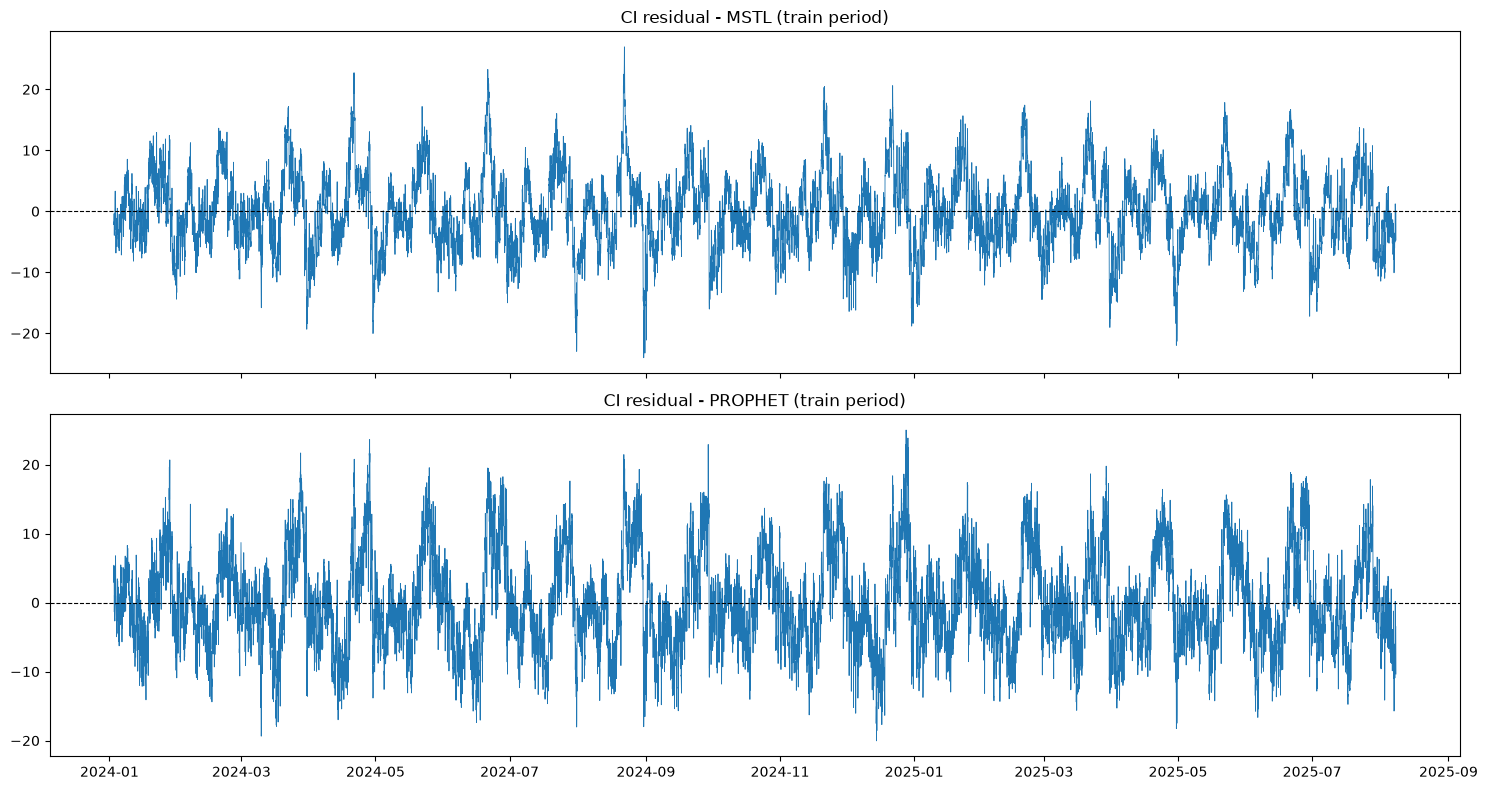

In [6]:
decompositions = {
    "mstl": mstl_decomposition,
    "prophet": prophet_decomposition,
}

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
for method, ax in zip(["mstl", "prophet"], axes):
    ax.plot(train_raw.index, decompositions[method]["CI_resid"].loc[train_raw.index], linewidth=0.6)
    ax.set_title(f"CI residual - {method.upper()} (train period)")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

## 4. Tuned hyperparameters (reused from `06_dani_dl_tuned.ipynb`)

```
Look-back  : 12
Layer type : lstm (best found; bilstm variants below reuse the same hyperparameter values)
Stacked    : 1 layer -> units=128, dropout=0.0
LR         : 0.001847
Batch size : 64
```

In [7]:
TUNED_LOOK_BACK = 12
TUNED_UNITS = 128
TUNED_DROPOUT = 0.0
TUNED_LR = 0.001847
TUNED_BATCH_SIZE = 64

FORECAST_HORIZON = 1
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

EPOCHS = 50
VALIDATION_SPLIT = 0.1

def make_early_stopping():
    return EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)


def build_residual_model(architecture, input_shape, output_dim):
    model = Sequential()

    if architecture == "lstm":
        model.add(LSTM(TUNED_UNITS, input_shape=input_shape))
    else:
        model.add(Bidirectional(LSTM(TUNED_UNITS), input_shape=input_shape))

    if TUNED_DROPOUT > 0:
        model.add(Dropout(TUNED_DROPOUT))

    model.add(Dense(output_dim))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=TUNED_LR),
        loss="mse",
        metrics=["mae"]
    )

    return model


print("Tuned hyperparameters loaded.")

Tuned hyperparameters loaded.


## 5. Residual feature/target assembly + one-step training & evaluation

`resid` untuk tiap target dipakai sebagai channel utama sliding-window (look-back=12), ditambah fitur
cyclical sebagai auxiliary. Setelah prediksi (dalam skala residual), hasilnya dijumlahkan kembali dengan
`reconstruction` (trend+seasonal / Prophet yhat) yang SUDAH DIKETAHUI di titik test manapun, untuk
mendapatkan forecast CI/RE dalam skala asli.

In [8]:
def evaluate(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    nonzero = y_true != 0
    mape = (
        np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100
        if np.any(nonzero) else np.nan
    )

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot

    return {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2": r2}


def build_residual_dataframe(decomp):
    df_resid = pd.DataFrame(index=df_core.index)
    df_resid["CI_resid"] = decomp["CI_resid"]
    df_resid["RE_resid"] = decomp["RE_resid"]
    df_resid[TEMPORAL_CYCLICAL] = cyclical_full[TEMPORAL_CYCLICAL]
    return df_resid


def get_feature_target_cols(target_group):
    if target_group == "CI":
        return ["CI_resid", *TEMPORAL_CYCLICAL], ["CI_resid"]
    elif target_group == "RE":
        return ["RE_resid", *TEMPORAL_CYCLICAL], ["RE_resid"]
    elif target_group == "MULTI":
        return ["CI_resid", "RE_resid", *TEMPORAL_CYCLICAL], ["CI_resid", "RE_resid"]
    raise ValueError("target_group must be CI, RE, or MULTI")

In [9]:
experiment_specs = [
    ("Uni-LSTM CI", "CI", "lstm"),
    ("Uni-LSTM RE", "RE", "lstm"),
    ("Multi-LSTM", "MULTI", "lstm"),
    ("BiLSTM CI", "CI", "bilstm"),
    ("BiLSTM RE", "RE", "bilstm"),
    ("BiLSTM Multi", "MULTI", "bilstm"),
]

decomposition_methods = ["mstl", "prophet"]

print("Total configs:", len(experiment_specs) * len(decomposition_methods))

Total configs: 12


## 6. Rolling-origin recursive multistep forecast

Dijalankan pakai model YANG SAMA dengan one-step (tidak ada training terpisah untuk multistep). Yang
di-recursive-forecast hanya kolom target residual — fitur cyclical di tiap langkah masa depan diambil
dari nilai ASLI (karena fitur kalender selalu diketahui di masa depan, bukan hasil prediksi).

In [10]:
MULTISTEP_HORIZON = 24
ORIGIN_STRIDE = 24
N_ORIGINS_MAX = 100


def rolling_origin_recursive_forecast(
    model, loader, test_scaled, feature_cols, target_cols,
    horizon=MULTISTEP_HORIZON, look_back=TUNED_LOOK_BACK,
    stride=ORIGIN_STRIDE, n_origins_max=N_ORIGINS_MAX
):
    data = test_scaled[feature_cols].values
    n = len(data)

    origins = list(range(look_back, n - horizon, stride))[:n_origins_max]
    target_idx = [feature_cols.index(c) for c in target_cols]

    per_origin_preds = []

    for origin in origins:
        history_window = data[origin - look_back: origin].copy()
        preds_scaled = []

        for h in range(horizon):
            X_step = history_window[np.newaxis, :, :]
            pred_scaled = model.predict(X_step, verbose=0).reshape(-1)
            preds_scaled.append(pred_scaled)

            next_row = data[origin + h].copy()
            for i, idx in enumerate(target_idx):
                next_row[idx] = pred_scaled[i]

            history_window = np.vstack([history_window[1:], next_row])

        preds_scaled = np.array(preds_scaled)
        preds_inv = loader.inverse_transform_predictions(
            preds_scaled, target_cols=target_cols, feature_cols=feature_cols
        )
        per_origin_preds.append((origin, preds_inv))

    return origins, per_origin_preds

## 7. Main experiment loop

In [11]:
all_results = []
all_horizon_results = []
all_models = {}
all_predictions = {}

for method in decomposition_methods:
    decomp = decompositions[method]
    df_resid = build_residual_dataframe(decomp)

    print("\n" + "=" * 80)
    print(f"DECOMPOSITION: {method.upper()}")
    print("=" * 80)

    for model_name, target_group, architecture in experiment_specs:
        print("\n" + "-" * 80)
        print(f"{model_name} | {method}")
        print("-" * 80)

        feature_cols, target_cols = get_feature_target_cols(target_group)

        loader = TimeSeriesDataLoader()
        train_scaled, test_scaled = loader.split_and_scale(
            df=df_resid, feature_cols=feature_cols, target_cols=target_cols, train_ratio=TRAIN_RATIO
        )

        X_train, y_train = loader.create_sliding_window(
            train_scaled, target_cols=target_cols,
            look_back=TUNED_LOOK_BACK, forecast_horizon=FORECAST_HORIZON
        )
        X_test, y_test = loader.create_sliding_window(
            test_scaled, target_cols=target_cols,
            look_back=TUNED_LOOK_BACK, forecast_horizon=FORECAST_HORIZON
        )

        output_dim = len(target_cols)

        model = build_residual_model(
            architecture, input_shape=(X_train.shape[1], X_train.shape[2]), output_dim=output_dim
        )

        history = model.fit(
            X_train, y_train,
            validation_split=VALIDATION_SPLIT,
            epochs=EPOCHS,
            batch_size=TUNED_BATCH_SIZE,
            callbacks=[make_early_stopping()],
            shuffle=False,
            verbose=0
        )

        # --- one-step evaluation ---
        pred_scaled = model.predict(X_test, verbose=0)
        if output_dim == 1:
            pred_scaled = pred_scaled.reshape(-1)

        resid_pred_inv = loader.inverse_transform_predictions(
            pred_scaled, target_cols=target_cols, feature_cols=feature_cols
        )

        # Reconstruction values aligned to the same test rows consumed by the window.
        plot_test_index = test_raw.index[TUNED_LOOK_BACK:]

        if target_group == "CI":
            final_pred = resid_pred_inv.reshape(-1) + decomp["CI_reconstruction"].loc[plot_test_index].values
            actual = df_core.loc[plot_test_index, CI_COL].values
            metrics = evaluate(actual, final_pred)
            all_results.append({"Decomposition": method, "Model": model_name, "Target": "CI", **metrics})
            all_predictions[(method, model_name)] = {"CI": final_pred, "RE": None}

        elif target_group == "RE":
            final_pred = resid_pred_inv.reshape(-1) + decomp["RE_reconstruction"].loc[plot_test_index].values
            actual = df_core.loc[plot_test_index, RE_COL].values
            metrics = evaluate(actual, final_pred)
            all_results.append({"Decomposition": method, "Model": model_name, "Target": "RE", **metrics})
            all_predictions[(method, model_name)] = {"CI": None, "RE": final_pred}

        else:
            ci_final = resid_pred_inv[:, 0] + decomp["CI_reconstruction"].loc[plot_test_index].values
            re_final = resid_pred_inv[:, 1] + decomp["RE_reconstruction"].loc[plot_test_index].values

            ci_metrics = evaluate(df_core.loc[plot_test_index, CI_COL].values, ci_final)
            re_metrics = evaluate(df_core.loc[plot_test_index, RE_COL].values, re_final)

            all_results.append({"Decomposition": method, "Model": model_name, "Target": "CI", **ci_metrics})
            all_results.append({"Decomposition": method, "Model": model_name, "Target": "RE", **re_metrics})
            all_predictions[(method, model_name)] = {"CI": ci_final, "RE": re_final}

        # --- rolling-origin recursive multistep evaluation ---
        origins, per_origin_preds = rolling_origin_recursive_forecast(
            model, loader, test_scaled, feature_cols, target_cols
        )

        for origin, preds_inv in per_origin_preds:
            preds_inv = np.atleast_2d(preds_inv)
            if preds_inv.shape[0] == 1 and len(target_cols) > 1:
                preds_inv = preds_inv.reshape(-1, len(target_cols))
            elif preds_inv.ndim == 1:
                preds_inv = preds_inv.reshape(-1, 1)

            origin_index = test_scaled.index[origin: origin + MULTISTEP_HORIZON]

            for h in range(MULTISTEP_HORIZON):
                ts = origin_index[h]
                for i, col in enumerate(target_cols):
                    target_name = "CI" if col.startswith("CI") else "RE"
                    recon_val = decomp[f"{target_name}_reconstruction"].loc[ts]
                    pred_final = preds_inv[h, i] + recon_val
                    actual_final = df_core.loc[ts, CI_COL if target_name == "CI" else RE_COL]

                    all_horizon_results.append({
                        "Decomposition": method,
                        "Model": model_name,
                        "Target": target_name,
                        "Horizon": h + 1,
                        "AbsError": abs(actual_final - pred_final)
                    })

        all_models[(method, model_name)] = {
            "model": model, "feature_cols": feature_cols, "target_cols": target_cols
        }

        print("Completed:", model_name, "|", method)


DECOMPOSITION: MSTL

--------------------------------------------------------------------------------
Uni-LSTM CI | mstl
--------------------------------------------------------------------------------
Split: Train=13996, Test=3500
Features scaled: 7
  Sliding window: X=(13984, 12, 7), y=(13984,)
  Sliding window: X=(3488, 12, 7), y=(3488,)
Completed: Uni-LSTM CI | mstl

--------------------------------------------------------------------------------
Uni-LSTM RE | mstl
--------------------------------------------------------------------------------
Split: Train=13996, Test=3500
Features scaled: 7
  Sliding window: X=(13984, 12, 7), y=(13984,)
  Sliding window: X=(3488, 12, 7), y=(3488,)
Completed: Uni-LSTM RE | mstl

--------------------------------------------------------------------------------
Multi-LSTM | mstl
--------------------------------------------------------------------------------
Split: Train=13996, Test=3500
Features scaled: 8
  Sliding window: X=(13984, 12, 8), y=(1398

In [12]:
results_df = pd.DataFrame(all_results)

print("=== ONE-STEP HYBRID MODEL EVALUATION ===")
display(results_df.sort_values(["Target", "Decomposition", "RMSE"]).reset_index(drop=True))

=== ONE-STEP HYBRID MODEL EVALUATION ===


,Decomposition,Model,Target,MAE,RMSE,MAPE (%),R2
0,mstl,BiLSTM CI,CI,1.518132,2.027636,0.259605,0.949495
1,mstl,BiLSTM Multi,CI,1.520163,2.027804,0.260004,0.949486
2,mstl,Uni-LSTM CI,CI,1.522801,2.037405,0.260416,0.949007
3,mstl,Multi-LSTM,CI,1.633345,2.158769,0.279543,0.942751
4,prophet,BiLSTM CI,CI,1.928152,2.477487,0.329732,0.924598
5,prophet,BiLSTM Multi,CI,1.935096,2.479573,0.331364,0.924471
6,prophet,Multi-LSTM,CI,1.962256,2.521056,0.336244,0.921923
7,prophet,Uni-LSTM CI,CI,1.998635,2.557164,0.342460,0.919671
8,mstl,Uni-LSTM RE,RE,0.162298,0.219943,1.030270,0.955739
9,mstl,BiLSTM RE,RE,0.167251,0.224362,1.063341,0.953943


In [13]:
horizon_results_df = pd.DataFrame(all_horizon_results)

horizon_summary = (
    horizon_results_df
    .groupby(["Decomposition", "Model", "Target", "Horizon"], as_index=False)["AbsError"]
    .mean()
    .rename(columns={"AbsError": "MAE_at_horizon"})
)

print("=== MULTISTEP MAE BY HORIZON (first few rows) ===")
display(horizon_summary.head(20))

=== MULTISTEP MAE BY HORIZON (first few rows) ===


,Decomposition,Model,Target,Horizon,MAE_at_horizon
0,mstl,BiLSTM CI,CI,1,1.272533
1,mstl,BiLSTM CI,CI,2,3.191674
2,mstl,BiLSTM CI,CI,3,3.628051
3,mstl,BiLSTM CI,CI,4,3.695169
4,mstl,BiLSTM CI,CI,5,3.696282
5,mstl,BiLSTM CI,CI,6,4.059185
6,mstl,BiLSTM CI,CI,7,3.735156
7,mstl,BiLSTM CI,CI,8,3.864279
8,mstl,BiLSTM CI,CI,9,4.259441
9,mstl,BiLSTM CI,CI,10,4.270462


In [17]:
horizon_summary[horizon_summary["Decomposition"] == "prophet"].head(20)

,Decomposition,Model,Target,Horizon,MAE_at_horizon
192,prophet,BiLSTM CI,CI,1,1.672801
193,prophet,BiLSTM CI,CI,2,3.319122
194,prophet,BiLSTM CI,CI,3,3.713963
195,prophet,BiLSTM CI,CI,4,3.594115
196,prophet,BiLSTM CI,CI,5,3.979474
197,prophet,BiLSTM CI,CI,6,5.111247
198,prophet,BiLSTM CI,CI,7,4.788093
199,prophet,BiLSTM CI,CI,8,5.526471
200,prophet,BiLSTM CI,CI,9,7.747241
201,prophet,BiLSTM CI,CI,10,8.096600


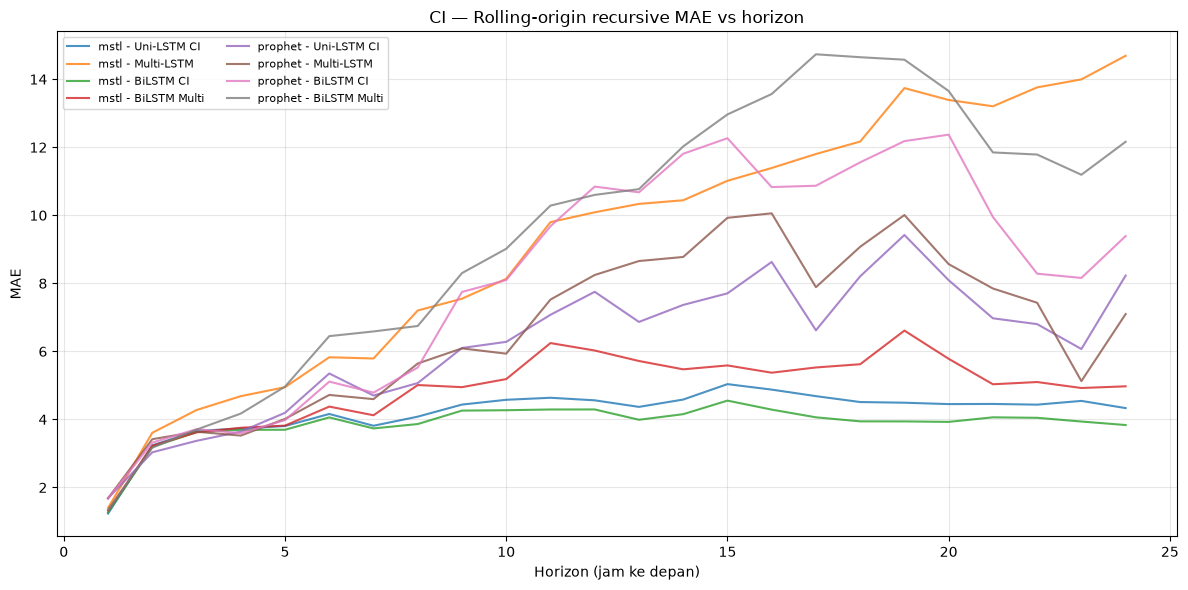

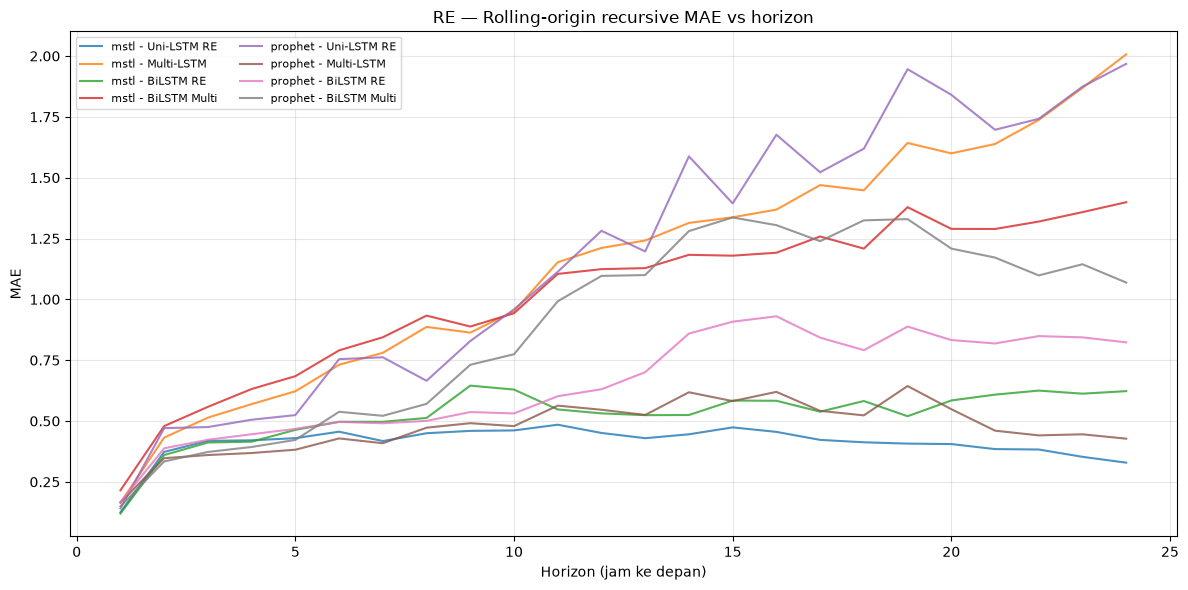

In [14]:
# Error-vs-horizon curves: does error grow with horizon, or stay flat?
for target in ["CI", "RE"]:
    fig, ax = plt.subplots(figsize=(12, 6))

    for method in decomposition_methods:
        for model_name, target_group, _ in experiment_specs:
            if target_group != "MULTI" and target_group != target:
                continue

            subset = horizon_summary[
                (horizon_summary["Decomposition"] == method)
                & (horizon_summary["Model"] == model_name)
                & (horizon_summary["Target"] == target)
            ].sort_values("Horizon")

            if len(subset) == 0:
                continue

            ax.plot(subset["Horizon"], subset["MAE_at_horizon"], label=f"{method} - {model_name}", alpha=0.8)

    ax.set_xlabel("Horizon (jam ke depan)")
    ax.set_ylabel("MAE")
    ax.set_title(f"{target} — Rolling-origin recursive MAE vs horizon")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

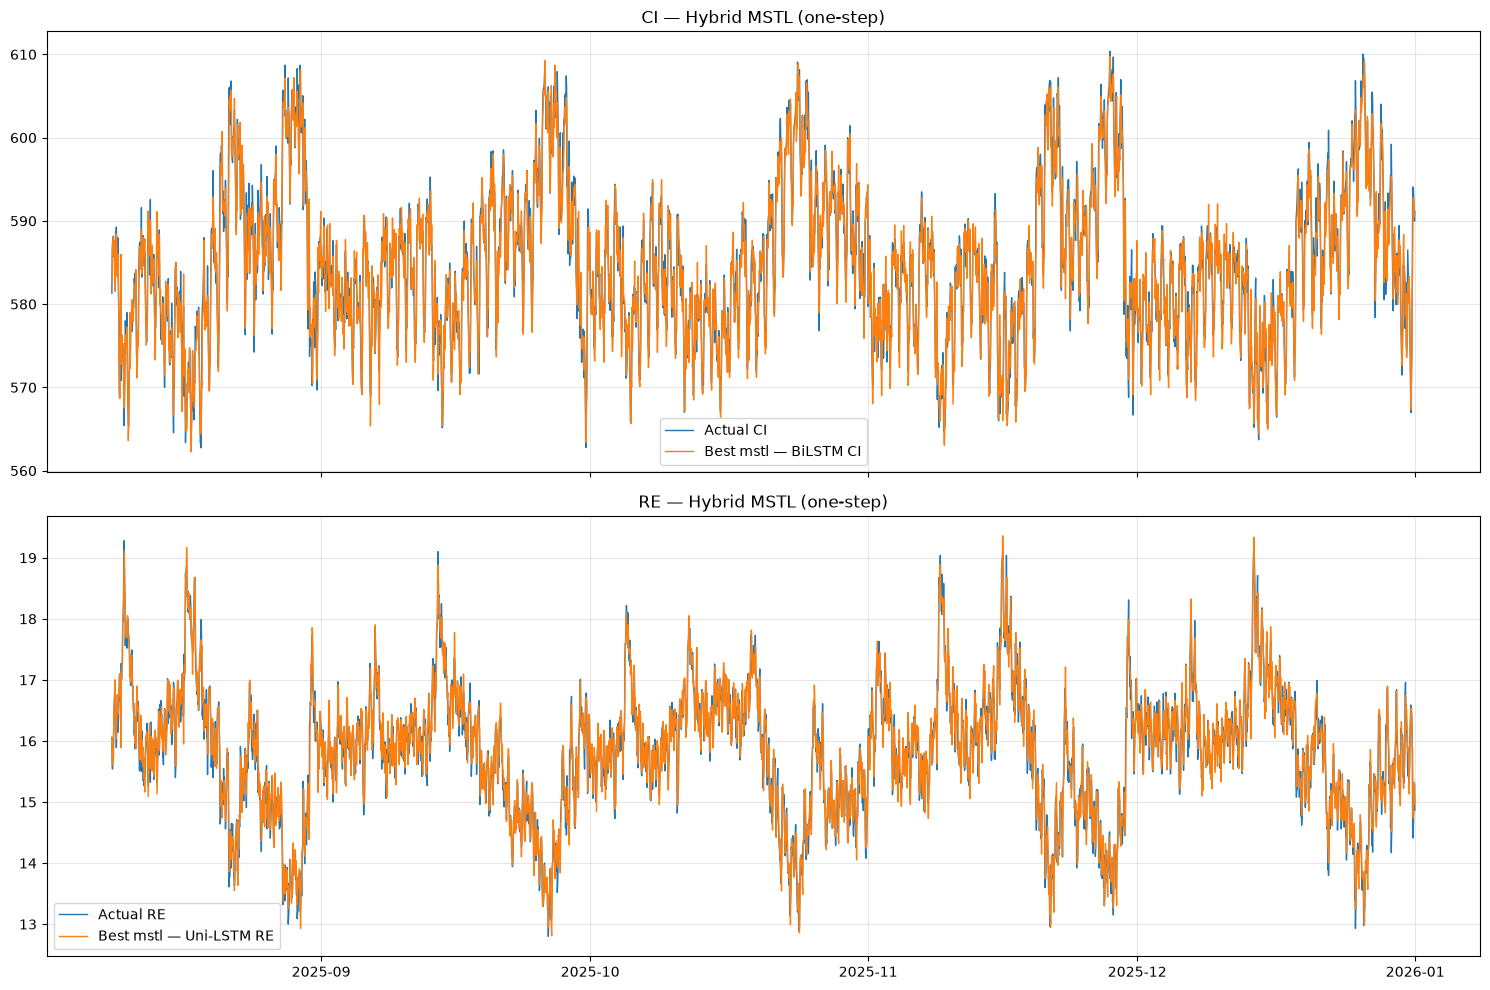

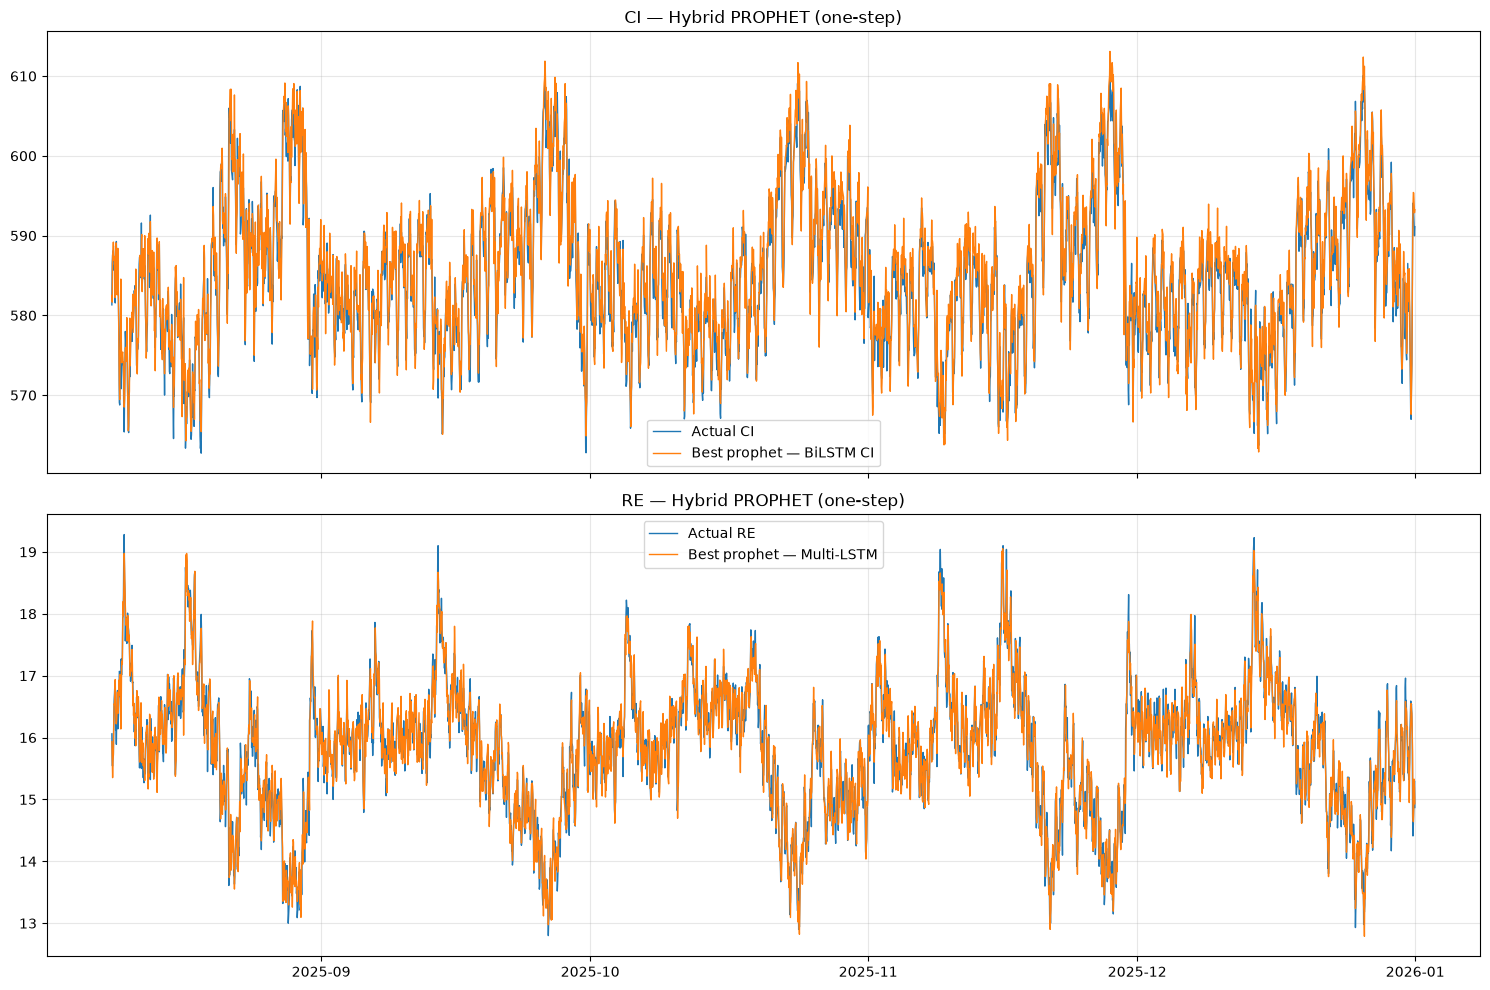

In [15]:
# One-step actual vs predicted, best model per decomposition method.
plot_test_index = test_raw.index[TUNED_LOOK_BACK:]

for method in decomposition_methods:
    subset = results_df[results_df["Decomposition"] == method].sort_values(["Target", "RMSE"])
    best_ci = subset[subset["Target"] == "CI"].iloc[0]
    best_re = subset[subset["Target"] == "RE"].iloc[0]

    fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

    axes[0].plot(plot_test_index, df_core.loc[plot_test_index, CI_COL].values, label="Actual CI", linewidth=1)
    axes[0].plot(
        plot_test_index, all_predictions[(method, best_ci["Model"])]["CI"],
        label=f"Best {method} — {best_ci['Model']}", linewidth=1
    )
    axes[0].set_title(f"CI — Hybrid {method.upper()} (one-step)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(plot_test_index, df_core.loc[plot_test_index, RE_COL].values, label="Actual RE", linewidth=1)
    axes[1].plot(
        plot_test_index, all_predictions[(method, best_re["Model"])]["RE"],
        label=f"Best {method} — {best_re['Model']}", linewidth=1
    )
    axes[1].set_title(f"RE — Hybrid {method.upper()} (one-step)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [16]:
results_dir = project_root / "results" / "hybrid"
results_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(results_dir / "07_dani_hybrid_onestep_metrics.csv", index=False)
horizon_summary.to_csv(results_dir / "07_dani_hybrid_multistep_horizon_mae.csv", index=False)

models_dir = project_root / "models" / "hybrid"
models_dir.mkdir(parents=True, exist_ok=True)

for (method, model_name), bundle in all_models.items():
    safe_name = model_name.lower().replace(" ", "_").replace("-", "")
    bundle["model"].save(models_dir / f"07_hybrid_{method}_{safe_name}.keras")

print("Saved:")
print(results_dir / "07_dani_hybrid_onestep_metrics.csv")
print(results_dir / "07_dani_hybrid_multistep_horizon_mae.csv")
print("12 hybrid models saved to", models_dir)

Saved:
/Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/results/hybrid/07_dani_hybrid_onestep_metrics.csv
/Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/results/hybrid/07_dani_hybrid_multistep_horizon_mae.csv
12 hybrid models saved to /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/models/hybrid


## Ringkasan

12 konfigurasi hybrid dievaluasi:
- **MSTL + {Uni-LSTM CI, Uni-LSTM RE, Multi-LSTM, BiLSTM CI, BiLSTM RE, BiLSTM Multi}**
- **Prophet + {Uni-LSTM CI, Uni-LSTM RE, Multi-LSTM, BiLSTM CI, BiLSTM RE, BiLSTM Multi}**

Dua output evaluasi:
1. **One-step** (`results_df`) — sebanding langsung dengan hasil notebook 04-06 (Direct/MSTL-Feature/Tuned).
2. **Multistep rolling-origin** (`horizon_summary`) — kurva error vs horizon (1-24 jam), jawaban langsung
   atas pertanyaan "apakah residual model ini aman di-recursive-forecast".

Yang perlu diperiksa dulu sebelum menyimpulkan:
- Apakah kurva MAE-vs-horizon **naik landai** (normal, expected) atau **naik tajam/meledak** (masih ada
  masalah, meski residual jauh lebih aman daripada trend).
- Bandingkan `results_df` (hybrid, one-step) vs metrik notebook 06 (tuned, non-hybrid) — apakah hybrid
  benar-benar mengungguli, mengingat hyperparameter di notebook ini belum di-tuning khusus untuk residual
  (itu tugas notebook 08).